# 06회 - 통신사 해지 고객 예측

#### Q01.

In [197]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

#### Q02.

In [198]:
from matplotlib import font_manager, rc
import platform

system = platform.system()

if system == 'Windows':
    rc('font', family='Malgun Gothic')

elif system == 'Darwin':  # macOS
    rc('font', family='AppleGothic')

else:  # Linux 등
    rc('font', family='NanumGothic')

plt.rcParams['axes.unicode_minus'] = False

In [199]:
telecom_df = pd.read_csv('../datasets/telecom.csv')
telecom_df.head()

,고객ID,연령,성별,지역,가입기간,월요금,총요금,상담횟수,데이터사용량,계약유형,해지여부
0,C00001,32.0,여성,서울,24,65500,1572000.0,1,15.2,1년약정,0
1,C00002,55.0,남성,경기,2,89000,178000.0,5,5.0,약정없음,1
2,C00003,28.0,여성,부산,48,45200,2169600.0,0,22.1,2년약정,0
3,C00004,41.0,남성,서울,1,105300,105300.0,4,8.5,약정없음,1
4,C00005,62.0,여성,기타,12,75000,NaN,2,10.2,약정없음,0


#### Q03. 데이터 시각화 및 해석

<Axes: xlabel='월요금', ylabel='Count'>

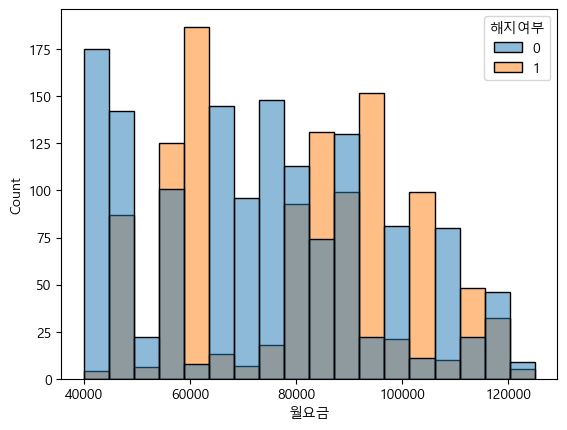

In [200]:
sns.histplot(
    data=telecom_df,
    x='월요금',
    hue='해지여부'
)

#### Q04.  결측치 처리1

In [201]:
문제4_1 = 'mean()'
문제4_2 = 'mode()[0]'

telecom_df['연령'].fillna(telecom_df['연령'].mean(), inplace=True)  
telecom_df['지역'].fillna(telecom_df['지역'].mode()[0], inplace=True)

C:\Users\kshelp\AppData\Local\Temp\ipykernel_5824\675422334.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  telecom_df['연령'].fillna(telecom_df['연령'].mean(), inplace=True)
C:\Users\kshelp\AppData\Local\Temp\ipykernel_5824\675422334.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chaine

0       서울
1       경기
2       부산
3       서울
4       기타
        ..
2557    기타
2558    서울
2559    경기
2560    부산
2561    대구
Name: 지역, Length: 2562, dtype: str

#### Q05. 결측치 처리2

In [202]:
telecom_df['총요금'].fillna((telecom_df['월요금'] * telecom_df['가입기간']), inplace=True)
telecom_df.drop_duplicates(subset=['고객ID'], inplace=True)

C:\Users\kshelp\AppData\Local\Temp\ipykernel_5824\1286882714.py:1: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  telecom_df['총요금'].fillna((telecom_df['월요금'] * telecom_df['가입기간']), inplace=True)


In [203]:
telecom_df.dropna(inplace=True)

#### Q06. 데이터 정제

In [204]:
telecom_df.drop(columns=['고객ID'], inplace=True)

telecom_df.drop(
    telecom_df[(telecom_df['월요금']>=110000) & (telecom_df['상담횟수']==0)].index,
    inplace=True
)

#### Q07. 범주형 변수 인코딩

In [205]:
telecom_df['성별'] = telecom_df['성별'].map({'여성':0, '남성':1})
telecom_df = pd.get_dummies(data=telecom_df, columns=['지역', '계약유형'])

#### Q08. 데이터 분리 및 분할

In [206]:
from sklearn.model_selection import train_test_split

X = telecom_df.drop(columns=['해지여부'])
y = telecom_df['해지여부']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

#### Q09.  수치형 데이터 스케일링

In [207]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_num = X_train[['연령', '가입기간', '월요금', '총요금']]
X_test_num = X_test[['연령', '가입기간', '월요금', '총요금']]

X_train_scaled = scaler.fit_transform(X_train_num)
X_test_scaled = scaler.transform(X_test_num)

In [208]:
cat_cols = [
    '지역_경기','지역_기타','지역_대구','지역_부산','지역_서울',
    '계약유형_1년약정','계약유형_2년약정','계약유형_약정없음',
    '성별'
]

X_train_scaled = pd.DataFrame(X_train_scaled,
                              index=X_train.index,
                              columns=X_train_num.columns)

X_test_scaled = pd.DataFrame(X_test_scaled,
                             index=X_test.index,
                             columns=X_test_num.columns)

X_train_scaled = pd.concat([X_train_scaled, X_train[cat_cols]], axis=1)
X_test_scaled  = pd.concat([X_test_scaled,  X_test[cat_cols]],  axis=1)

#### Q10. 머신러닝 모델 구축

In [209]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

lr_model = LogisticRegression(random_state=42, max_iter=1000, C=0.1)
lr_model.fit(X_train_scaled, y_train)

# 모델 정의
rf_model = RandomForestClassifier(
    random_state=42, 
    n_estimators=50, 
    max_depth=5, 
    min_samples_split=5
)

# 모델 학습
rf_model.fit(X_train_scaled, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",50
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",5
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_t

#### Q11. 머신러닝 모델 성능 비교

In [210]:
from sklearn.metrics import accuracy_score, f1_score

# 예측
lr_pred = lr_model.predict(X_test_scaled)
rf_pred = rf_model.predict(X_test_scaled)

# 평가
lr_acc = accuracy_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
rf_acc = accuracy_score(y_test, rf_pred)
rf_f1 = f1_score(y_test, rf_pred)

print(f"lr_acc: {lr_acc:.4f}")
print(f"lr_f1: {lr_f1:.4f}")
print(f"rf_acc: {rf_acc:.4f}")
print(f"rf_f1: {rf_f1:.4f}")

정답_11 = '랜덤포레스트'

lr_acc: 0.9814
lr_f1: 0.9785
rf_acc: 0.9930
rf_f1: 0.9920


#### Q12. 딥러닝 모델 설계 및 컴파일

In [211]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

tf.random.set_seed(10)

In [212]:
model = Sequential()
model.add(Dense(64, activation='selu', input_shape=(X_train_scaled.shape[1],)))
model.add(BatchNormalization())
model.add(Dense(32, activation='selu'))
model.add(BatchNormalization())
model.add(Dense(16, activation='selu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

d:\dev\workspace\ai\aice_associate\.venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Q13. 딥러닝 모델 학습 (fit)

In [220]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stopping = EarlyStopping(
    monitor='val_loss',    
    patience=5,            
    restore_best_weights=True
)

model_checkpoint = ModelCheckpoint(
    filepath='best_model.keras',     
    monitor='val_loss',           
    save_best_only=True,
    verbose=1 
)

# 반드시 compile 먼저 수행
model.compile(
    optimizer='adam',              # 최적화 알고리즘
    loss='binary_crossentropy',    # 손실 함수
    metrics=['accuracy']           # 평가 지표
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=128,
    callbacks=[early_stopping, model_checkpoint],
    verbose=1 # 학습 과정 출력 (1：상세 출력)
)

Epoch 1/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9919 - loss: 0.0289
Epoch 1: val_loss improved from None to 0.03088, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 9s 147ms/step - accuracy: 0.9920 - loss: 0.0264 - val_accuracy: 0.9942 - val_loss: 0.0309
Epoch 2/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.9906 - loss: 0.0313
Epoch 2: val_loss did not improve from 0.03088
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step - accuracy: 0.9935 - loss: 0.0230 - val_accuracy: 0.9942 - val_loss: 0.0310
Epoch 3/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9935 - loss: 0.0318
Epoch 3: val_loss improved from 0.03088 to 0.02942, saving model to best_model.keras

Epoch 3: finished saving model to best_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 91ms/step - accuracy: 0.9949 - loss: 0.0248 - val_accuracy: 0.9942 - val_loss: 0.0294
Epoch 4/50
10/11 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9929 - loss: 

#### Q14. 데이터 예측 및 결과 저장

In [217]:
pred_data = np.array([0.279998, -0.416104, -0.378967, -0.411085, False, False, True, False, False, True, False, False, 0]).reshape(1, -1)

In [242]:
pred_proba = model.predict(pred_data)

print("정답_14 =", np.where(pred_proba>=0.5, 1, 0).reshape(1,)[0])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step
정답_14 = 0
